# Taller de NLP: Análisis de Sentimientos con IMDB

En este taller trabajaremos con el dataset de reseñas de películas de IMDB para hacer análisis de sentimientos usando dos enfoques distintos: Bag of Words y Word2Vec. Compararemos su desempeño y entenderemos sus diferencias prácticas.

## 1. Carga de datos y preprocesamiento

Cargaremos el dataset, limpiamos el texto y lo preparamos para el análisis.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Instalación de librerías necesarias (si es necesario)
#!pip install nltk gensim scikit-learn
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 16.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.1
    Uninstalling scipy-1.16.1:
      Successfully uninstalled scipy-1.16.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatibl

In [ ]:
import nltk
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews


In [ ]:
import os

files = os.listdir(path)
print("Archivos en el directorio:", files)

Archivos en el directorio: ['IMDB Dataset.csv']


In [ ]:
# Leer el archivo CSV desde el path
data = pd.read_csv(os.path.join(path, "IMDB Dataset.csv"))
print(data.shape)
data.head()

(50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
data['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [ ]:
data['target'] = data['sentiment'].map({'positive': 1, 'negative': 0})
data.head()

,review,sentiment,target
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1


In [ ]:
# Preprocesamiento básico
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = re.sub(r"[^a-zA-Z]", " ", text)
    tokens = nltk.word_tokenize(text.lower())
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

data['clean_review'] = data['review'].apply(preprocess)
data.head()

,review,sentiment,target,clean_review
0,One of the other reviewers has mentioned that ...,positive,1,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,positive,1,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,positive,1,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,0,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1,petter mattei love time money visually stunnin...


In [ ]:
data['review'][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [ ]:
data['clean_review'][0]

'one reviewer mentioned watching oz episode hooked right exactly happened br br first thing struck oz brutality unflinching scene violence set right word go trust show faint hearted timid show pull punch regard drug sex violence hardcore classic use word br br called oz nickname given oswald maximum security state penitentary focus mainly emerald city experimental section prison cell glass front face inwards privacy high agenda em city home many aryan muslim gangsta latino christian italian irish scuffle death stare dodgy dealing shady agreement never far away br br would say main appeal show due fact go show dare forget pretty picture painted mainstream audience forget charm forget romance oz mess around first episode ever saw struck nasty surreal say ready watched developed taste oz got accustomed high level graphic violence violence injustice crooked guard sold nickel inmate kill order get away well mannered middle class inmate turned prison bitch due lack street skill prison experi

## 2. Análisis con Bag of Words
Vectorizaremos las reseñas con CountVectorizer y entrenaremos un clasificador simple.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    data['clean_review'], data['sentiment'], test_size=0.2, random_state=42
)

vectorizer = CountVectorizer()
X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow = vectorizer.transform(X_test)

clf_bow = LogisticRegression()
clf_bow.fit(X_train_bow, y_train)
y_pred_bow = clf_bow.predict(X_test_bow)

print(classification_report(y_test, y_pred_bow))

              precision    recall  f1-score   support

    negative       0.89      0.88      0.88      4961
    positive       0.88      0.89      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
print(X_train_bow)

  (0, 38958)	1
  (0, 3870)	1
  (0, 44159)	3
  (0, 25716)	1
  (0, 63423)	1
  (0, 44701)	1
  (0, 70566)	1
  (0, 28605)	1
  (0, 44937)	1
  (0, 53707)	1
  (0, 46619)	1
  (0, 14032)	1
  (0, 1910)	1
  (0, 68322)	2
  (0, 72392)	1
  (0, 51115)	4
  (0, 19170)	1
  (0, 11768)	1
  (0, 42108)	1
  (0, 18344)	1
  (0, 77998)	1
  (0, 35056)	1
  (0, 10698)	1
  (0, 31628)	1
  (0, 4976)	1
  :	:
  (39999, 11557)	1
  (39999, 58752)	1
  (39999, 35410)	1
  (39999, 17461)	1
  (39999, 9456)	1
  (39999, 37790)	1
  (39999, 73646)	1
  (39999, 23818)	1
  (39999, 18726)	1
  (39999, 72576)	1
  (39999, 32882)	1
  (39999, 36214)	1
  (39999, 24883)	1
  (39999, 56221)	1
  (39999, 62678)	1
  (39999, 24281)	1
  (39999, 27116)	1
  (39999, 19304)	1
  (39999, 11957)	1
  (39999, 44800)	1
  (39999, 71907)	1
  (39999, 52286)	1
  (39999, 30480)	1
  (39999, 19148)	1
  (39999, 13980)	1


In [ ]:
y_pred_bow

array(['negative', 'positive', 'negative', ..., 'positive', 'negative',
       'positive'], dtype=object)

In [ ]:
X_test[33553]

'really liked summerslam due look arena curtain look overall interesting reason anyways could one best summerslam ever wwf lex luger main event yokozuna time ok huge fat man v strong man glad time changed terrible main event like every match luger terrible match card razor ramon v ted dibiase steiner brother v heavenly body shawn michael v curt hening event shawn named big monster body guard diesel irs v kid bret hart first take doink take jerry lawler stuff hart lawler always interesting ludvig borga destroyed marty jannetty undertaker took giant gonzalez another terrible match smoking gunns tatanka took bam bam bigelow headshrinkers yokozuna defended world title lex luger match boring terrible ending however deserves'

## 3. Análisis con Word2Vec
Usaremos `gensim` para crear vectores de palabras y representar las reseñas como el promedio de sus vectores.

In [ ]:
from gensim.models import Word2Vec

# Tokenizar cada reseña para Word2Vec
tokenized_reviews = [review.split() for review in data['clean_review']]

# Entrenar modelo Word2Vec
w2v_model = Word2Vec(sentences=tokenized_reviews, vector_size=100, window=5, min_count=1, workers=4)

def get_avg_vector(tokens):
    vectors = [w2v_model.wv[w] for w in tokens if w in w2v_model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)

X_w2v = np.array([get_avg_vector(tokens) for tokens in tokenized_reviews])
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(X_w2v, data['sentiment'], test_size=0.2, random_state=42)

clf_w2v = LogisticRegression()
clf_w2v.fit(X_train_w2v, y_train_w2v)
y_pred_w2v = clf_w2v.predict(X_test_w2v)

print(classification_report(y_test_w2v, y_pred_w2v))

              precision    recall  f1-score   support

    negative       0.86      0.85      0.86      4961
    positive       0.86      0.87      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [ ]:
tokenized_reviews[0]

['one',
 'reviewer',
 'mentioned',
 'watching',
 'oz',
 'episode',
 'hooked',
 'right',
 'exactly',
 'happened',
 'br',
 'br',
 'first',
 'thing',
 'struck',
 'oz',
 'brutality',
 'unflinching',
 'scene',
 'violence',
 'set',
 'right',
 'word',
 'go',
 'trust',
 'show',
 'faint',
 'hearted',
 'timid',
 'show',
 'pull',
 'punch',
 'regard',
 'drug',
 'sex',
 'violence',
 'hardcore',
 'classic',
 'use',
 'word',
 'br',
 'br',
 'called',
 'oz',
 'nickname',
 'given',
 'oswald',
 'maximum',
 'security',
 'state',
 'penitentary',
 'focus',
 'mainly',
 'emerald',
 'city',
 'experimental',
 'section',
 'prison',
 'cell',
 'glass',
 'front',
 'face',
 'inwards',
 'privacy',
 'high',
 'agenda',
 'em',
 'city',
 'home',
 'many',
 'aryan',
 'muslim',
 'gangsta',
 'latino',
 'christian',
 'italian',
 'irish',
 'scuffle',
 'death',
 'stare',
 'dodgy',
 'dealing',
 'shady',
 'agreement',
 'never',
 'far',
 'away',
 'br',
 'br',
 'would',
 'say',
 'main',
 'appeal',
 'show',
 'due',
 'fact',
 'go',
 

In [ ]:
X_train_w2v

array([[ 0.4644113 , -0.17810155,  0.10162675, ..., -0.4935493 ,
         0.01462819,  0.02146098],
       [ 0.5275186 , -0.5260121 ,  0.29311228, ..., -0.66078234,
         0.15136479, -0.01790942],
       [ 0.18661228,  0.48489034,  0.5920512 , ..., -0.15192609,
         0.37602496, -0.54651463],
       ...,
       [ 0.6576039 , -0.5090123 , -0.16221856, ..., -0.87961394,
         0.01944374,  0.34082702],
       [ 0.3664834 , -0.35219377,  0.44281206, ..., -0.5697236 ,
         0.10767832, -0.21714742],
       [ 0.95940197, -0.3787098 ,  0.51034147, ..., -0.57776946,
        -0.20594259, -0.03777428]], dtype=float32)

In [ ]:
print(w2v_model)

Word2Vec<vocab=89818, vector_size=100, alpha=0.025>


## 4. Comparación y Conclusiones
Podemos observar qué método funciona mejor, qué ventajas tienen, y cómo mejorar los modelos.
- ¿Qué diferencias observás en las métricas?
- ¿Cuál fue más rápido?
- ¿Qué problemas aparecen en cada enfoque?

## 5. Visualización de los datos y embeddings
Visualizaremos los vectores de reseñas usando t-SNE para entender mejor la separación entre clases.

ValueError: 'c' argument must be a color, a sequence of colors, or a sequence of numbers, not 0        positive
1        positive
2        positive
3        negative
4        positive
           ...   
49995    positive
49996    negative
49997    negative
49998    negative
49999    negative
Name: sentiment, Length: 50000, dtype: object

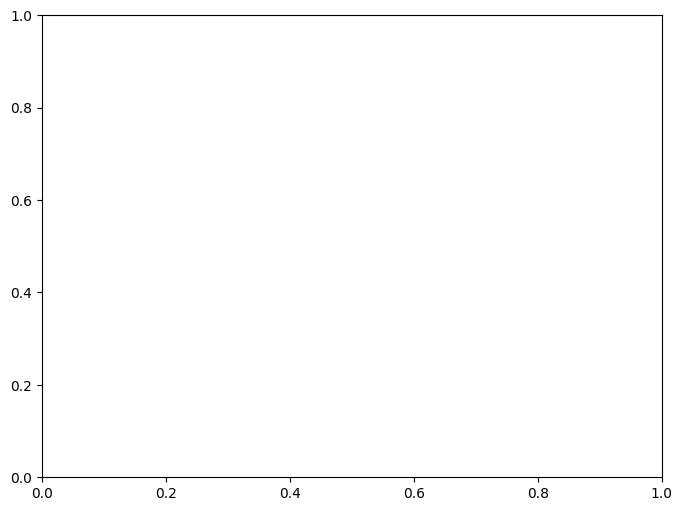

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Reducir a 2D usando t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_embedded = tsne.fit_transform(X_w2v)

# Graficar
plt.figure(figsize=(8, 6))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=data['sentiment'], cmap='coolwarm', alpha=0.6)
plt.title("Visualización de reseñas usando Word2Vec + t-SNE")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.colorbar(label='Sentimiento')
plt.show()

In [ ]:
data['sentiment'] = data['sentiment'].map({'positive': 1, 'negative': 0})

# Vectorización con TF-IDF
vectorizer = TfidfVectorizer(max_features=1000)
X_tfidf = vectorizer.fit_transform(data['review'])

# Reducción con t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_embedded = tsne.fit_transform(X_tfidf.toarray())

# Gráfico
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=df['sentiment'], cmap='coolwarm', alpha=0.6)
plt.title("Visualización de reseñas con TF-IDF + t-SNE")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.colorbar(scatter, label='Sentimiento')
plt.show()

## 6. Modelado de Tópicos con LDA
Usaremos LDA (Latent Dirichlet Allocation) para descubrir los temas más comunes en las reseñas.

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

# Usar la matriz de BoW ya creada
lda = LatentDirichletAllocation(n_components=2, random_state=42)
lda.fit(X_train_bow)

# Mostrar palabras más representativas por tópico
vocab = vectorizer.get_feature_names_out()
for idx, topic in enumerate(lda.components_):
    print(f"Tópico #{idx+1}:")
    print([vocab[i] for i in topic.argsort()[-10:]])
    print()